# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 40     |  |
| :-------------|:-------------|
| Raphaelle Tam | 6504272 |
| Tom Vermeulen | 6441637 |
| Owen van der Wal| 6545297 |

| Planning Groep: 40     |Tijdstip / Tijdspanne  |
| :-------------|:-------------|
|Checken of sensoren werken|11:45|
| Ideeen schetsen | 12:15 |
| Mijlpaal 1: Ontwerpstap criteria| 14:15 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 15:30 |
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:30-15:45 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Foto_Schetsen.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtensensor | Boxing Machine | - Nauwkeurig kracht meten tussen de 100N en 2000N met nauwkeurige stappen van 5N. Hij mag een fout marge hebben van 10N. - Hij moet groot genoeg zijn dat een hele hand er op past dus minstens rond de 30cm. - Hij moet krachten tussen de 100N en 1000N meten, maar hij moet ook 10.000 N kunnen volhouden zonder dat hij kapot valt|
|Temperatuursensor | Thermostaat meet temperatuur en past temp aan | Hij moet de temperatuur in verschillende kamers nauwkeurig kunnen meten voor temperaturen tussen de 10 en 30 graden. Hij moet dit kunnen op 1 decimaal nauwkeurig. Waarbij een foutmarge van 0,05 graden toegestaan is.|
|Lichtsensor | Als het licht is buiten dan gaat de gordijn vanzelf dicht | Hij moet nauwkeurig tussen de 0 en 10.000 lux kunnen meten. Als de LUX boven de 8.000 dan zullen de gordijnen half dicht gaan en als hij boven de 10.000 LUX en onder de 450 lUX meet gaan de gordijnen compleet dicht.|


Groep 40 heeft gekozen voor de lichtsensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Wij willen voor nacht cups op de sensor doen zodat het helemaal donker wordt. Voor daglicht gaan wij naar buiten.
 ![Alt](Foto_Schetsen2.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
Lichtintensiteit
2. Over welk bereik ga je deze variabelen veranderen?
van donker naar daglicht. 0 naar 100.000 lux
3. Wat ga je allemaal meten?
De lichtintensiteit bij bepaalde belichting met je telefoon en verschil in spanning bij de arduino. En hiermee zorgen dat we de waarden gelijk kunnen stellen. En calibreren
4. Hoeveel metingen ga je doen?
10, Vooral zorgen dat we een idee hebben van lichtmarges
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Ja het gaat lukken voor onze toepassing, om bij felle dag licht de gordijnen dicht te laten gaan. Alleen is nog de vraag of de nauwkeurigheid helemaal klopt.


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Foto_Opstelling1.jpeg "meetopstelling student") 
  ![Alt](Foto_Opstelling2.jpeg "meetopstelling student")
   ![Alt](Foto_Opstelling3.jpeg "meetopstelling student")
   We hebben voor de telefoonsensor hetzelfde gedaan. Dus de telefoon lag dan onder de bekertjes.
   In de foto's is te zien hoe we de arduino met het moederbord hebben samengevoegd. En daarbij ook de lichtsensor. We kunnen zien dat met het bekertje de sensor wordt bedekt en zo er 'donker' wordt nagebootst

## *Opdracht 6*: Meten en fitten, Leerdoel

In [44]:
# Zet hier jouw data in een voor jou handig formaat
telefoon_data = (28,450,5000,1900, 2630, 950, 420, 7100,4200, 9700)
sensor_data = (30,108,320,180, 192, 128, 87, 513, 368, 520)

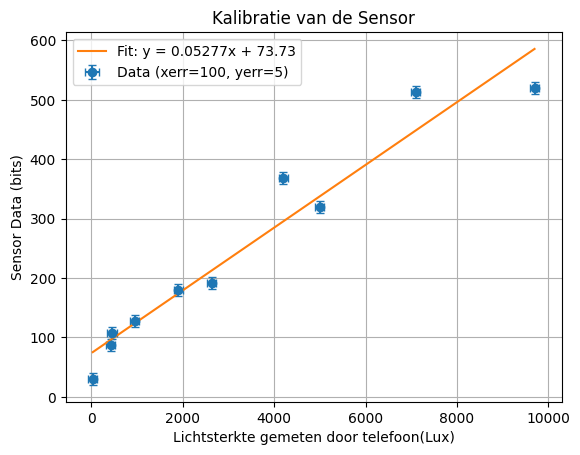

In [46]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def line(x, a, b):
    return a * x + b

sensor_err = np.full_like(sensor_data, 10, dtype=float)        
telefoon_err = np.full_like(telefoon_data, 100.0, dtype=float)  

popt, pcov = curve_fit(
    line,
    telefoon_data,
    sensor_data,
    sigma=sensor_err,
    absolute_sigma=True
)
a, b = popt
da, db = np.sqrt(np.diag(pcov))

x_test = np.linspace(np.min(telefoon_data), np.max(telefoon_data), 200)
y_fit = line(x_test, a, b)


plt.figure()
plt.errorbar(
    telefoon_data, sensor_data,
    xerr=telefoon_err, yerr=sensor_err,
    fmt='o', capsize=3,
    label='Data (xerr=100, yerr=5)'
)
plt.plot(x_test, y_fit, '-', label=f"Fit: y = {a:.4g}x + {b:.4g}")
plt.title('Kalibratie van de Sensor')
plt.xlabel('Lichtsterkte gemeten door telefoon(Lux)')
plt.ylabel('Sensor Data (bits)')
plt.grid()
plt.legend()
plt.show()



## *Opdracht 7*: Iteratie nodig?

Nee er is geen iteratie nodig voor onze metingen en het model, omdat wij aan de hand van de verzamelde data kunnen vaststellen dat de sensor gebruikt kan worden.Dit doen we aan de hand van onze criteria, aangezien wij kunnen zien dat bij onze criteria wij van 0 tot 10000 willen kunnen meten en dat bij 8000 een drempelwaarde is waarbij de gordijnen halfdicht moeten, en bij 10000 een drempelwaarde waarbij ze volledig dicht moeten. Er hoeft dus niet super duper nauwkeurig gemeten te worden, we moeten alleen bewijzen dat het mogelijk is om binenn de marge te vallen

## *Opdracht 8*: Conclusie, leerdoel
De metingen wijken af van de verwachte waarden en liggen ver naast de curvefit.  De drempelwaardes die wij gebruikt hebben zijn tussen de 0, 450 ,8000 en 10000 LUX, door deze drempelwaardes en de gevormde intervallen van de drempelwaardes kunnen we vaststellen dat de sensor alsnog gebruikt kan worden voor onze bedachte toepassing, waarbij we gordijnen aan de hand van lichtinterval automatisch open en dicht willen laten gaan.


## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Als naar de ingevoegde foto's van de opstelling gekeken wordt dan is te zien dat er een schakeling gebouwd is om data te kunnen verkrijgen uit de lichtsensor.

Licht kort toe wat er in de foto te zien is.
 ![Alt](Foto_Opstelling1.jpeg "meetopstelling student")
  ![Alt](Foto_Opstelling2.jpeg "meetopstelling student")
   ![Alt](Foto_Opstelling3.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtensensor | Boxing Machine | - Nauwkeurig kracht meten tussen de 100N en 2000N met nauwkeurige stappen van 5N. Hij mag een fout marge hebben van 10N. - Hij moet groot genoeg zijn dat een hele hand er op past dus minstens rond de 30cm. - Hij moet krachten tussen de 100N en 1000N meten, maar hij moet ook 10.000 N kunnen volhouden zonder dat hij kapot valt|
|Temperatuursensor | Thermostaat meet temperatuur en past temp aan | Hij moet de temperatuur in verschillende kamers nauwkeurig kunnen meten voor temperaturen tussen de 10 en 30 graden. Hij moet dit kunnen op 1 decimaal nauwkeurig. Waarbij een foutmarge van 0,05 graden toegestaan is.|
|Lichtsensor | Als het licht is buiten dan gaat de gordijn vanzelf dicht | Hij moet nauwkeurig tussen de 0 en 10.000 lux kunnen meten. Als de LUX boven de 8.000 dan zullen de gordijnen half dicht gaan en als hij boven de 10.000 LUX en onder de 450 lUX meet gaan de gordijnen compleet dicht.|


Groep 40 heeft gekozen voor de lichtsensor. 

Vooraf zijn er criteria vastgesteld om te zorgen dat het bedachte model, kan werken aan de hand van de gekozen sensor. Door naar de afbeeldingen te kijken kan gezien worden dat er gebruik is gemaakt van de ontwerpcyclus, door de verschillende weergegeven ideeen en de schets gemaakt van de onderzoeksopstelling.

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

## *Opdracht 6*: Meten en fitten, Leerdoel
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def line(x, a, b):
    return a * x + b

sensor_err = np.full_like(sensor_data, 10, dtype=float)        
telefoon_err = np.full_like(telefoon_data, 100.0, dtype=float)  

popt, pcov = curve_fit(
    line,
    telefoon_data,
    sensor_data,
    sigma=sensor_err,
    absolute_sigma=True
)
a, b = popt
da, db = np.sqrt(np.diag(pcov))

x_test = np.linspace(np.min(telefoon_data), np.max(telefoon_data), 200)
y_fit = line(x_test, a, b)


plt.figure()
plt.errorbar(
    telefoon_data, sensor_data,
    xerr=telefoon_err, yerr=sensor_err,
    fmt='o', capsize=3,
    label='Data (xerr=100, yerr=5)'
)
plt.plot(x_test, y_fit, '-', label=f"Fit: y = {a:.4g}x + {b:.4g}")
plt.title('Kalibratie van de Sensor')
plt.xlabel('Telefoon Data')
plt.ylabel('Sensor Data')
plt.grid()
plt.legend()
plt.show()



## *Opdracht 8*: Conclusie, leerdoel